---

## **Use Case 2: Oracle Enterprise Order-to-Cash Exception Orchestration**

### **Problem Statement**

**Title:**
Supervisor Agent for Oracle Fusion-style Enterprise Operations (Finance + Supply Chain + Compliance)

### **Problem Description**

This use case demonstrates a supervisor agent coordinating multiple enterprise specialists for a realistic Oracle business workflow.
The objective is to resolve order-to-cash exceptions across operations, finance, and compliance in one orchestrated flow.

Typical enterprise question:
"A high-value order is delayed, inventory is short, customer credit risk increased, and export compliance must be checked. What should we do next?"

### **Architecture Overview**

```
                         ┌──────────────────────────────┐
                         │   Enterprise Supervisor      │
                         │   (Workflow Orchestrator)    │
                         └──────────────┬───────────────┘
                                        │
        ┌───────────────┬───────────────┼───────────────┬────────────────┐
        │               │               │               │                │
┌────────────────┐ ┌────────────────┐ ┌────────────────┐ ┌────────────────┐
│ Inventory Agent│ │ Credit Agent   │ │ Compliance Agent│ │ Procurement Agent│
│ Stock & ATP    │ │ Risk & Limits  │ │ Trade Screening │ │ Supplier Options │
└────────────────┘ └────────────────┘ └────────────────┘ └────────────────┘
```

### **Input**

| Field      | Description |
| ---------- | ----------- |
| `messages` | User query describing an enterprise exception across order, inventory, credit, and compliance |

### **Agent Role Descriptions**

| Agent | Purpose | Tool(s) |
| ---- | ------- | ------- |
| **Supervisor** | Decides which specialist to call and in what sequence | None |
| **Inventory Agent** | Checks stock, ATP, and fulfillment options | `check_inventory()` |
| **Credit Agent** | Assesses customer risk and credit hold recommendations | `assess_credit_risk()` |
| **Compliance Agent** | Validates sanctions/export compliance risk | `screen_trade_compliance()` |
| **Procurement Agent** | Suggests alternate suppliers and lead times | `find_alternate_supplier()` |

### **Expected Output**

- A consolidated action plan (release/hold/split/expedite)
- Clear rationale by domain (supply, risk, compliance, sourcing)
- A recommended execution sequence for Oracle operations teams

### **Execution Workflow Summary**

1. Supervisor interprets enterprise exception.
2. Routes sub-tasks to specialist agents.
3. Combines tool results into one operational recommendation.
4. Returns a concise decision brief for operations and finance stakeholders.

---

In [1]:
from datetime import datetime

INVENTORY_LEDGER = {
    "XJ-220": {"on_hand": 72, "reserved": 18, "inbound_qty": 120, "inbound_days": 4},
    "AX-15": {"on_hand": 210, "reserved": 40, "inbound_qty": 0, "inbound_days": 0},
}

CREDIT_PROFILES = {
    "C-458": {"segment": "Strategic", "credit_limit": 250000, "utilized": 195000, "overdue_30_plus": 62000, "dso": 74},
    "C-112": {"segment": "Standard", "credit_limit": 100000, "utilized": 42000, "overdue_30_plus": 3000, "dso": 42},
}

COUNTRY_RISK = {
    "uae": "medium",
    "india": "low",
    "germany": "low",
    "iran": "restricted",
    "north korea": "restricted",
    "syria": "restricted",
}

SUPPLIER_OPTIONS = {
    "XJ-220": [
        {"supplier": "GlobalParts GmbH", "lead_days": 5, "cost_premium_pct": 8, "quality_ppm": 210},
        {"supplier": "Delta Source APAC", "lead_days": 8, "cost_premium_pct": 3, "quality_ppm": 340},
        {"supplier": "PrimeMek US", "lead_days": 3, "cost_premium_pct": 12, "quality_ppm": 190},
    ],
    "AX-15": [
        {"supplier": "NeoSupply", "lead_days": 7, "cost_premium_pct": 4, "quality_ppm": 250},
    ],
}

CONTROLLED_PRODUCTS = {"dual-use-chipset", "crypto-module", "high-precision-sensor"}



In [3]:
def check_inventory(item_code: str, required_qty: int) -> str:
    """Compute ATP, shortage, and fulfillment recommendation for an item."""
    item = INVENTORY_LEDGER.get(item_code, {"on_hand": 0, "reserved": 0, "inbound_qty": 0, "inbound_days": 0})
    atp = max(item["on_hand"] - item["reserved"], 0)
    shortage = max(required_qty - atp, 0)
    fill_rate = round((min(atp, required_qty) / max(required_qty, 1)) * 100, 1)

    if shortage == 0:
        action = "Release full shipment immediately from ATP stock."
    elif item["inbound_qty"] >= shortage:
        action = f"Split order: ship {atp} now and {shortage} after inbound in {item['inbound_days']} days."
    else:
        action = f"Critical shortage: only {atp} can ship now; escalate for alternate sourcing of {shortage}."

    return (
        f"[Inventory Assessment] Item={item_code} | Required={required_qty} | ATP={atp} | "
        f"Shortage={shortage} | FillRate={fill_rate}% | Recommendation={action}"
    )

In [4]:
def assess_credit_risk(customer_id: str, order_value: float) -> str:
    """Evaluate credit utilization and recommend release policy."""
    profile = CREDIT_PROFILES.get(
        customer_id,
        {"segment": "Unknown", "credit_limit": 50000, "utilized": 20000, "overdue_30_plus": 0, "dso": 45},
    )
    projected_utilized = profile["utilized"] + order_value
    util_ratio = projected_utilized / max(profile["credit_limit"], 1)
    overdue_ratio = profile["overdue_30_plus"] / max(profile["credit_limit"], 1)

    if util_ratio > 1.0 or overdue_ratio > 0.25:
        decision = "HOLD and request Finance Controller override with payment commitment."
    elif util_ratio > 0.9 or profile["dso"] > 70:
        decision = "PARTIAL RELEASE with credit watch and accelerated collection plan."
    else:
        decision = "RELEASE under standard credit policy."

    return (
        f"[Credit Assessment] Customer={customer_id} | Segment={profile['segment']} | "
        f"Limit={profile['credit_limit']} | ProjectedUtilization={util_ratio:.1%} | "
        f"Overdue30+={profile['overdue_30_plus']} | DSO={profile['dso']} | Decision={decision}"
    )

In [5]:
def screen_trade_compliance(country: str, product_type: str) -> str:
    """Run country and product risk checks for trade compliance."""
    risk = COUNTRY_RISK.get(country.lower(), "medium")
    controlled = product_type.lower() in CONTROLLED_PRODUCTS

    if risk == "restricted":
        decision = "BLOCK SHIPMENT pending legal clearance and denied-party recheck."
    elif risk == "medium" and controlled:
        decision = "REVIEW REQUIRED: export license and end-use certificate mandatory."
    elif risk == "medium":
        decision = "Proceed with enhanced due diligence and consignee verification."
    else:
        decision = "No major compliance blockers detected."

    return (
        f"[Compliance Assessment] Country={country} | CountryRisk={risk} | Product={product_type} | "
        f"Controlled={controlled} | Decision={decision}"
    )

In [6]:
def find_alternate_supplier(item_code: str) -> str:
    """Rank supplier alternatives by lead time, cost premium, and quality risk."""
    options = SUPPLIER_OPTIONS.get(item_code, [])
    if not options:
        return f"[Procurement Assessment] No prequalified alternate suppliers found for {item_code}."

    ranked = sorted(options, key=lambda x: (x["lead_days"], x["cost_premium_pct"], x["quality_ppm"]))
    best = ranked[0]
    backup = ranked[1] if len(ranked) > 1 else None

    recommendation = (
        f"PrimaryAlt={best['supplier']} (Lead={best['lead_days']}d, Premium=+{best['cost_premium_pct']}%, QualityPPM={best['quality_ppm']})"
    )
    if backup:
        recommendation += (
            f" | BackupAlt={backup['supplier']} (Lead={backup['lead_days']}d, Premium=+{backup['cost_premium_pct']}%, QualityPPM={backup['quality_ppm']})"
        )

    return f"[Procurement Assessment] Item={item_code} | {recommendation}"



In [8]:
from langchain_openai import ChatOpenAI

from langgraph_supervisor import create_supervisor
from langgraph.prebuilt import create_react_agent


# Initialize OpenAI model
import os
model = ChatOpenAI(temperature=0, api_key=os.environ["OPENAI_API_KEY"], model="gpt-4o-mini")


/Users/ingledarshan/.local/share/virtualenvs/AH-KbrtVpZi/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
inventory_agent = create_react_agent(
    model=model,
    tools=[check_inventory],
    name="inventory_expert",
    prompt="You are an Oracle supply chain inventory specialist. Use ATP, shortage, and split-shipment logic in your response.",
)

credit_agent = create_react_agent(
    model=model,
    tools=[assess_credit_risk],
    name="credit_expert",
    prompt="You are an Oracle finance credit specialist. Use utilization, overdue, and DSO metrics for decisions.",
)

compliance_agent = create_react_agent(
    model=model,
    tools=[screen_trade_compliance],
    name="compliance_expert",
    prompt="You are an Oracle trade compliance specialist. Evaluate country risk, product sensitivity, and shipment decision.",
)

procurement_agent = create_react_agent(
    model=model,
    tools=[find_alternate_supplier],
    name="procurement_expert",
    prompt="You are an Oracle procurement specialist. Recommend primary and backup supplier options with tradeoffs.",
)

oracle_workflow = create_supervisor(
    [inventory_agent, credit_agent, compliance_agent, procurement_agent],
    model=model,
    prompt=(
        "You are an enterprise operations supervisor for Oracle-style order-to-cash orchestration. "
        "Call specialist agents, aggregate their assessments, and return a decision memo with: "
        "1) Ship/Hold recommendation, 2) Financial controls, 3) Compliance actions, "
        "4) Sourcing fallback, and 5) 24-48 hour execution plan."
    ),
)

oracle_app = oracle_workflow.compile()

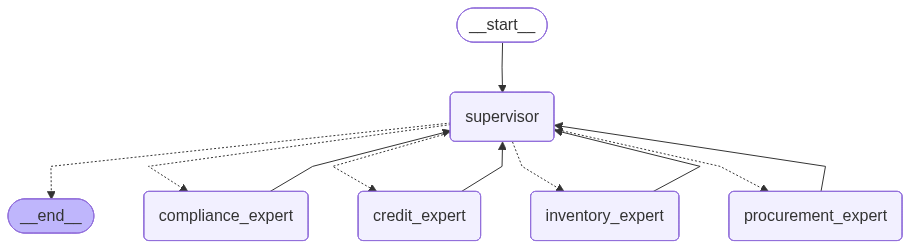

In [10]:
from IPython.display import display, Image
display(Image(oracle_app.get_graph().draw_mermaid_png()))

In [11]:
oracle_result = oracle_app.invoke({
    "messages": [
        {
            "role": "user",
            "content": (
                "Order O2C-7781 for product XJ-220 (qty 150) is delayed. "
                "Customer C-458 has increased credit exposure, shipment destination is UAE, "
                "and primary supplier missed SLA. Provide an action plan."
            ),
        }
    ]
})

for msg in oracle_result["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Order O2C-7781 for product XJ-220 (qty 150) is delayed. Customer C-458 has increased credit exposure, shipment destination is UAE, and primary supplier missed SLA. Provide an action plan.
================================== Ai Message ==================================
Name: compliance_expert

### Action Plan for Order O2C-7781

1. **Assess Country and Product Risk:**
   - **Country:** UAE
   - **Country Risk Level:** Medium
   - **Product:** XJ-220
   - **Controlled Status:** Not controlled
   - **Recommendation:** Proceed with enhanced due diligence and consignee verification.

2. **Address Customer Credit Exposure:**
   - Review the increased credit exposure for Customer C-458.
   - Consider implementing stricter payment terms or requiring additional guarantees before proceeding with the shipment.

3. **Supplier Performance:**
   - Engage with the primary supplier to understand the reasons for missing t

---

## **Use Case 3: Real-Time Fraud Detection Intelligence Network**

### **Problem Statement**

**Title:**
Peer-to-Peer Fraud Detection using LangGraph Swarm (Network) Architecture

---

### **Problem Description**

This use case implements the **fully connected Network topology** from the architecture diagram — where **every agent can directly hand off to any peer**, with no central supervisor bottleneck.

A suspicious transaction triggers a dynamic peer-to-peer investigation chain:

* **Transaction Analyst** — examines raw transaction signals (amount, country, channel, hour)
* **Behavioral Profiler** — compares the transaction against the customer's historical baseline
* **Risk Scorer** — computes a composite fraud risk score (0–100) using all signals
* **Case Manager** — executes the final disposition (approve / challenge / block / escalate)

Unlike the **Supervisor pattern** used in Use Cases 1 & 2, each agent in this **Swarm** independently decides which peer to route to next — enabling dynamic, context-driven collaboration with no single point of control.

---

### **Architecture Overview**

```
                        ┌────────────────────────────┐
                        │    Transaction Analyst     │
                        │ [analyze_transaction_      │
                        │       details()]           │
                        └───┬────────┬──────────┬───┘
                            │        │          │
             ┌──────────────┘        │          └──────────────┐
             │                       │                         │
 ┌───────────▼────────────┐          │          ┌─────────────▼──────────┐
 │   Behavioral Profiler  │◄─────────┼─────────►│      Risk Scorer       │
 │ [analyze_customer_     │          │          │  [score_fraud_risk()]  │
 │     behavior()]        │◄────────►│◄────────►│                        │
 └───────────┬────────────┘          │          └─────────────┬──────────┘
             │                       │                         │
             └──────────────┐        │        ┌────────────────┘
                            │        │        │
                        ┌───▼────────▼────────▼───┐
                        │       Case Manager      │
                        │  [execute_case_action()]│
                        └─────────────────────────┘

     Every agent ↔ Every agent  (Fully Connected Peer-to-Peer Network)
```

---

### **Supervisor vs Network — Key Differences**

| Feature | Supervisor (Use Cases 1 & 2) | Network / Swarm (Use Case 3) |
| ------- | ---------------------------- | ---------------------------- |
| Routing control | Central supervisor decides | Each agent decides its next peer |
| Topology | Hub-and-spoke | Fully connected mesh |
| Flexibility | Fixed routing policy | Dynamic, context-driven routing |
| Fault tolerance | Single point of failure | Distributed decision-making |
| Use when | Clear task delegation | Complex, interleaved collaboration |

---

### **Agent Role Descriptions**

| Agent | Purpose | Tool | Handoff Logic |
| ----- | ------- | ---- | ------------- |
| **Transaction Analyst** | Detect raw anomaly signals | `analyze_transaction_details()` | → Behavioral Profiler |
| **Behavioral Profiler** | Profile vs customer baseline | `analyze_customer_behavior()` | → Risk Scorer |
| **Risk Scorer** | Compute composite fraud score (0–100) | `score_fraud_risk()` | → Case Manager |
| **Case Manager** | Execute final disposition | `execute_case_action()` | Terminal |

---

### **Input**

| Field | Description |
| ----- | ----------- |
| `messages` | User query containing transaction ID, customer ID, and transaction context |

```json
{
  "role": "user",
  "content": "Investigate transaction TXN-9001 for customer CUS-101: $4850 at electronics store in Romania at 3 AM."
}
```

---

### **Output**

| Output Type | Example |
| ----------- | ------- |
| Final Response | `"Transaction TXN-9001 BLOCKED. Card suspended. Fraud case FC-9001 opened."` |
| Execution Path | Analyst → Profiler → Scorer → Manager |
| Disposition | `approve` / `challenge` / `block` / `escalate` |

---

### **Example Queries and Expected Flow**

| User Query | Expected Path | Outcome |
| ---------- | ------------- | ------- |
| TXN-9001 — $4,850, electronics, Romania, 3 AM (CUS-101) | Analyst → Profiler → Scorer → Manager | **BLOCK** (HIGH risk) |
| TXN-9002 — $42.50, grocery, India, 2 PM (CUS-202) | Analyst → Scorer → Manager | **APPROVE** (LOW risk) |

---


In [12]:
# ── Mock Reference Data ──────────────────────────────────────────────────────

# TRANSACTION_DB - This is a sample database of recent transactions, including details like amount, currency, merchant category, country, channel, time of transaction, and device fingerprint match status. This data can be used for fraud detection or customer behavior analysis.
TRANSACTION_DB = {
    "TXN-9001": {
        "amount": 4850.00,
        "currency": "USD",
        "merchant_category": "electronics",
        "country": "romania",
        "channel": "card_present",
        "hour_of_day": 3,
        "device_fingerprint_match": False,
    },
    "TXN-9002": {
        "amount": 42.50,
        "currency": "USD",
        "merchant_category": "grocery",
        "country": "india",
        "channel": "card_present",
        "hour_of_day": 14,
        "device_fingerprint_match": True,
    },
}

# CUSTOMER_PROFILES - This contains detailed profiles of customers, including their home country, average transaction amount, maximum transaction in the last 30 days, preferred spending categories, percentage of transactions made at night, percentage of international transactions, and number of open disputes. This information can be used for personalized marketing or fraud risk assessment.
CUSTOMER_PROFILES = {
    "CUS-101": {
        "home_country": "usa",
        "avg_txn_amount": 120.00,
        "max_txn_30d": 650.00,
        "preferred_categories": ["grocery", "dining", "travel"],
        "night_txn_pct": 0.04,   # 4 % of transactions between midnight–5 AM
        "intl_txn_pct": 0.05,    # 5 % international
        "open_disputes": 2,
    },
    "CUS-202": {
        "home_country": "india",
        "avg_txn_amount": 35.00,
        "max_txn_30d": 180.00,
        "preferred_categories": ["grocery", "utilities"],
        "night_txn_pct": 0.02,
        "intl_txn_pct": 0.01,
        "open_disputes": 0,
    },
}

# HIGH_RISK_COUNTRIES - This is a set of countries that are considered high risk for fraudulent transactions based on historical data and fraud patterns. Transactions originating from or involving these countries may require additional scrutiny or be automatically flagged for review.
HIGH_RISK_COUNTRIES = {"romania", "nigeria", "ukraine", "belarus", "myanmar"}


In [13]:
# analyze_transaction_details() - This function examines raw transaction attributes such as amount, country, device match, and time of day to flag potential anomaly signals. It aggregates these signals to determine an overall severity level for the transaction.
def analyze_transaction_details(transaction_id: str) -> str:
    """Examine raw transaction attributes and flag anomaly signals."""
    txn = TRANSACTION_DB.get(
        transaction_id,
        {"amount": 0, "currency": "USD", "merchant_category": "unknown",
         "country": "unknown", "channel": "unknown", "hour_of_day": 12,
         "device_fingerprint_match": True},
    )
    signals = []
    if txn["amount"] > 1000:
        signals.append(f"HIGH_VALUE(${txn['amount']:.2f})")
    if txn["country"] in HIGH_RISK_COUNTRIES:
        signals.append(f"HIGH_RISK_COUNTRY({txn['country'].upper()})")
    if not txn["device_fingerprint_match"]:
        signals.append("DEVICE_MISMATCH")
    if txn["hour_of_day"] < 5:
        signals.append(f"ODD_HOUR({txn['hour_of_day']:02d}:00)")

    anomaly_count = len(signals)
    severity = "HIGH" if anomaly_count >= 3 else "MEDIUM" if anomaly_count >= 1 else "LOW"

    return (
        f"[Transaction Analysis] TXN={transaction_id} | "
        f"Amount=${txn['amount']:.2f} | Category={txn['merchant_category']} | "
        f"Country={txn['country']} | Channel={txn['channel']} | "
        f"Hour={txn['hour_of_day']:02d}:00 | Signals={signals or ['NONE']} | "
        f"Severity={severity}"
    )


# analyze_customer_behavior() - This function compares a transaction against the customer's historical baseline by analyzing deviations in transaction amount, location, category, and timing. It aggregates these behavioral deviations to assign a risk level for the transaction.
def analyze_customer_behavior(customer_id: str, transaction_id: str) -> str:
    """Compare the transaction against the customer's historical baseline."""
    profile = CUSTOMER_PROFILES.get(
        customer_id,
        {"home_country": "unknown", "avg_txn_amount": 100, "max_txn_30d": 500,
         "preferred_categories": [], "night_txn_pct": 0.05, "intl_txn_pct": 0.10,
         "open_disputes": 0},
    )
    txn = TRANSACTION_DB.get(transaction_id, {})
    deviations = []

    if txn:
        if txn["amount"] > profile["max_txn_30d"] * 2: # Amount is more than 2x the customer's max in the last 30 days
            deviations.append(f"AMOUNT_SPIKE(x{txn['amount'] / max(profile['avg_txn_amount'], 1):.1f}_avg)") # Amount is significantly higher than the customer's average transaction amount
        if txn["country"] != profile["home_country"] and txn.get("country") not in {"", "unknown"}:
            deviations.append(f"FOREIGN_TXN({txn['country'].upper()})")
        if txn["merchant_category"] not in profile["preferred_categories"]:
            deviations.append(f"UNUSUAL_CATEGORY({txn['merchant_category']})")
        if txn["hour_of_day"] < 5 and profile["night_txn_pct"] < 0.05:
            deviations.append("UNUSUAL_HOUR_FOR_PROFILE")

    risk_level = "HIGH" if len(deviations) >= 3 else "MEDIUM" if len(deviations) >= 1 else "LOW"

    return (
        f"[Behavioral Profile] Customer={customer_id} | "
        f"AvgTxn=${profile['avg_txn_amount']:.2f} | Max30d=${profile['max_txn_30d']:.2f} | "
        f"OpenDisputes={profile['open_disputes']} | "
        f"Deviations={deviations or ['NONE']} | BehaviorRisk={risk_level}"
    )

# score_fraud_risk() - This function computes a composite fraud risk score on a scale of 0 to 100 by aggregating various transaction and behavioral signals. It then provides a recommendation for how to handle the transaction based on the computed risk score.
def score_fraud_risk(transaction_id: str, customer_id: str) -> str:
    """Compute a composite fraud risk score (0–100) from transaction and behavioural signals."""
    txn = TRANSACTION_DB.get(transaction_id, {})
    profile = CUSTOMER_PROFILES.get(customer_id, {})

    score = 0
    breakdown = []

    # Transaction signals
    if txn.get("amount", 0) > 1000:
        score += 25; breakdown.append("HIGH_VALUE(+25)")
    if txn.get("country", "") in HIGH_RISK_COUNTRIES:
        score += 30; breakdown.append("HIGH_RISK_COUNTRY(+30)")
    if not txn.get("device_fingerprint_match", True):
        score += 20; breakdown.append("DEVICE_MISMATCH(+20)")
    if txn.get("hour_of_day", 12) < 5:
        score += 10; breakdown.append("ODD_HOUR(+10)")

    # Behavioural signals
    if txn.get("amount", 0) > profile.get("max_txn_30d", 99999) * 2:
        score += 15; breakdown.append("AMOUNT_SPIKE(+15)")
    if profile.get("open_disputes", 0) >= 2:
        score += 10; breakdown.append("OPEN_DISPUTES(+10)")

    score = min(score, 100)
    if score >= 70:
        recommendation = "block"
    elif score >= 45:
        recommendation = "challenge"
    elif score >= 25:
        recommendation = "escalate"
    else:
        recommendation = "approve"

    return (
        f"[Risk Score] TXN={transaction_id} | Customer={customer_id} | "
        f"Score={score}/100 | Factors={breakdown} | "
        f"Recommendation={recommendation.upper()}"
    )

# execute_case_action() - This function takes a fraud case disposition action (approve, challenge, block, or escalate) and generates a detailed execution summary that outlines the steps taken for that action, such as monitoring, customer contact, alerts, and case management.
def execute_case_action(transaction_id: str, customer_id: str, action: str) -> str:
    """Execute fraud case disposition: approve, challenge, block, or escalate."""
    action = action.lower().strip()
    if action not in {"approve", "challenge", "block", "escalate"}:
        action = "escalate"

    case_ref = f"FC-{transaction_id[-4:]}"
    outcomes = {
        "approve": (
            f"Transaction {transaction_id} APPROVED. "
            "Enhanced monitoring active for next 48 h."
        ),
        "challenge": (
            f"OTP challenge issued to customer {customer_id}. "
            f"Transaction {transaction_id} on 5-min hold pending verification."
        ),
        "block": (
            f"Transaction {transaction_id} BLOCKED. Card suspended for {customer_id}. "
            f"SMS/email alert sent. Fraud case {case_ref} opened."
        ),
        "escalate": (
            f"Transaction {transaction_id} ESCALATED to Fraud Ops ({case_ref}). "
            f"Manual review SLA: 15 min. {customer_id} flagged for outbound contact."
        ),
    }

    return f"[Case Action] Action={action.upper()} | {outcomes[action]}"


In [14]:
from langgraph.graph import MessagesState, StateGraph, START
from langgraph.prebuilt import create_react_agent
from langgraph_supervisor import create_handoff_tool

# ── Handoff Tools (one per destination — gives every agent full peer access) ──

transfer_to_behavioral_profiler = create_handoff_tool(
    agent_name="behavioral_profiler", name="transfer_to_behavioral_profiler"
)
transfer_to_risk_scorer = create_handoff_tool(
    agent_name="risk_scorer", name="transfer_to_risk_scorer"
)
transfer_to_case_manager = create_handoff_tool(
    agent_name="case_manager", name="transfer_to_case_manager"
)
transfer_to_transaction_analyst = create_handoff_tool(
    agent_name="transaction_analyst", name="transfer_to_transaction_analyst"
)

# ── Specialist Agents (domain tool + handoff tools for each peer) ─────────────

transaction_analyst = create_react_agent(
    model=model,
    tools=[
        analyze_transaction_details,
        transfer_to_behavioral_profiler,
        transfer_to_risk_scorer,
        transfer_to_case_manager,
    ],
    name="transaction_analyst",
    prompt=(
        "You are a fraud transaction analyst. "
        "Use analyze_transaction_details() to examine raw signals for the given transaction ID. "
        "After analysis, call transfer_to_behavioral_profiler to hand off for historical comparison."
    ),
)

behavioral_profiler = create_react_agent(
    model=model,
    tools=[
        analyze_customer_behavior,
        transfer_to_transaction_analyst,
        transfer_to_risk_scorer,
        transfer_to_case_manager,
    ],
    name="behavioral_profiler",
    prompt=(
        "You are a customer behavior profiler. "
        "Use analyze_customer_behavior() to compare the transaction against the customer baseline. "
        "After profiling, call transfer_to_risk_scorer to compute a composite fraud score."
    ),
)

risk_scorer = create_react_agent(
    model=model,
    tools=[
        score_fraud_risk,
        transfer_to_transaction_analyst,
        transfer_to_behavioral_profiler,
        transfer_to_case_manager,
    ],
    name="risk_scorer",
    prompt=(
        "You are a fraud risk scoring specialist. "
        "Use score_fraud_risk() to compute a composite risk score (0-100) and a disposition recommendation. "
        "After scoring, call transfer_to_case_manager to execute the final action."
    ),
)

case_manager = create_react_agent(
    model=model,
    tools=[
        execute_case_action,
        transfer_to_transaction_analyst,
        transfer_to_behavioral_profiler,
        transfer_to_risk_scorer,
    ],
    name="case_manager",
    prompt=(
        "You are a fraud case manager. "
        "Use execute_case_action() with the action (approve / challenge / block / escalate) "
        "based on the risk score recommendation. Provide a final clear summary of the outcome."
    ),
)

# ── Build Network Graph (Fully Connected Peer-to-Peer Mesh via StateGraph) ────
#
#   No central supervisor — each agent decides its own next peer via handoff tools.
#   Every agent node is reachable from every other agent node.
#   Entry point: transaction_analyst (START -> transaction_analyst).

builder = StateGraph(MessagesState)
builder.add_node("transaction_analyst", transaction_analyst)
builder.add_node("behavioral_profiler", behavioral_profiler)
builder.add_node("risk_scorer", risk_scorer)
builder.add_node("case_manager", case_manager)

builder.add_edge(START, "transaction_analyst")

fraud_app = builder.compile()
print("Fraud Detection Network compiled successfully.")
print("Nodes:", list(fraud_app.get_graph().nodes.keys()))


Fraud Detection Network compiled successfully.
Nodes: ['__start__', 'transaction_analyst', 'behavioral_profiler', 'risk_scorer', 'case_manager', '__end__']


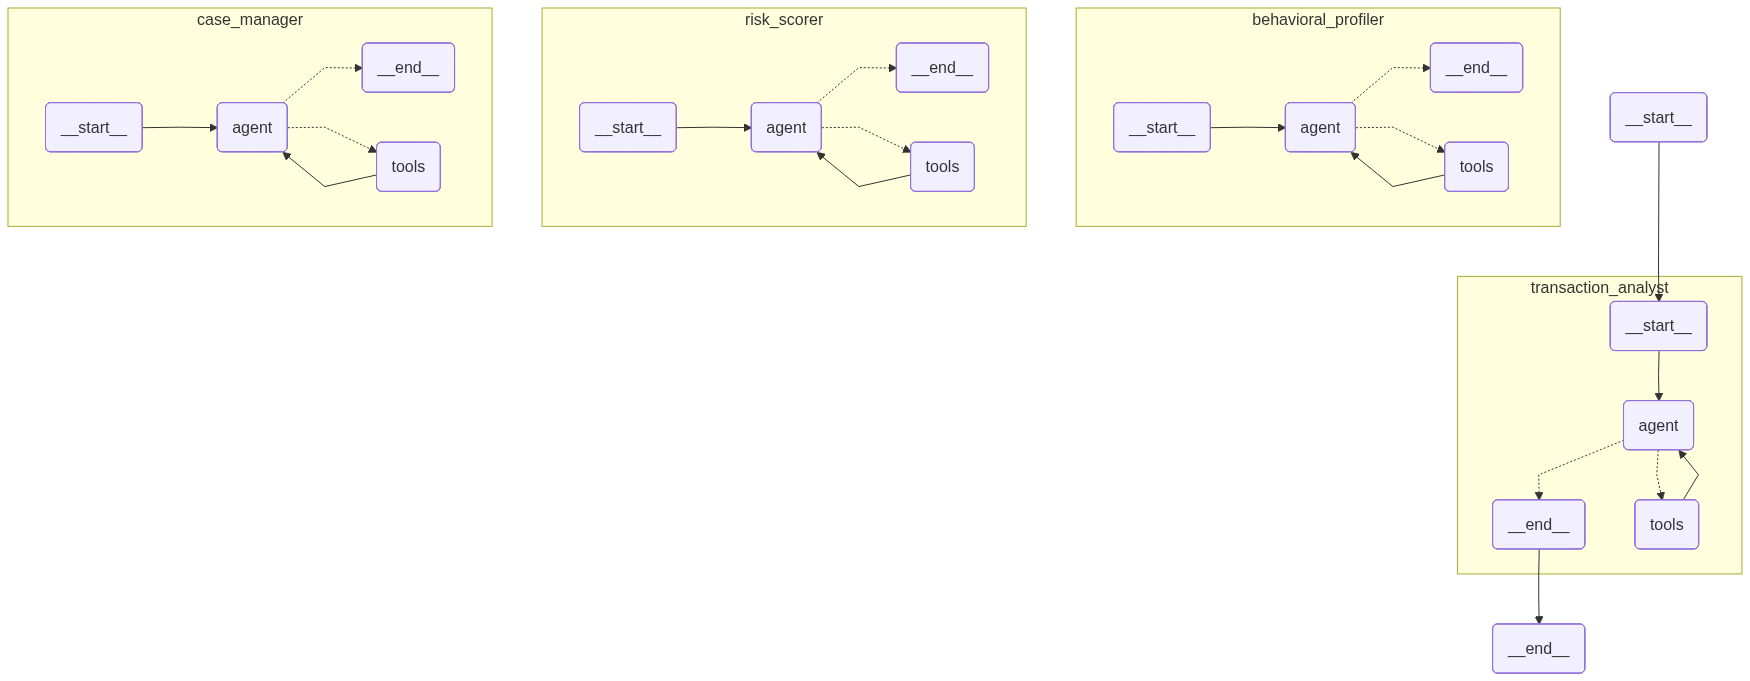

In [15]:
from IPython.display import display, Image

# xray=1 expands one level of subgraphs to reveal internal agent nodes and
# the handoff-tool edges that form the fully-connected peer-to-peer mesh.
display(Image(fraud_app.get_graph(xray=1).draw_mermaid_png()))


In [16]:
# ── Example 1: High-Risk Transaction (expected → BLOCK) ──────────────────────
fraud_result_1 = fraud_app.invoke({
    "messages": [
        {
            "role": "user",
            "content": (
                "Investigate transaction TXN-9001 for customer CUS-101. "
                "Transaction details: $4,850 at an electronics store in Romania at 3 AM. "
                "Device fingerprint does not match. Determine if this is fraud and take action."
            ),
        }
    ]
})

print("=" * 70)
print("EXAMPLE 1 — HIGH-RISK TRANSACTION (TXN-9001 | CUS-101)")
print("=" * 70)
for msg in fraud_result_1["messages"]:
    msg.pretty_print()


EXAMPLE 1 — HIGH-RISK TRANSACTION (TXN-9001 | CUS-101)
================================ Human Message =================================

Investigate transaction TXN-9001 for customer CUS-101. Transaction details: $4,850 at an electronics store in Romania at 3 AM. Device fingerprint does not match. Determine if this is fraud and take action.
================================== Ai Message ==================================
Name: transaction_analyst
Tool Calls:
  analyze_transaction_details (call_OUzcxxSkT05RRdoA5XB2uZmZ)
 Call ID: call_OUzcxxSkT05RRdoA5XB2uZmZ
  Args:
    transaction_id: TXN-9001
================================= Tool Message =================================
Name: analyze_transaction_details

[Transaction Analysis] TXN=TXN-9001 | Amount=$4850.00 | Category=electronics | Country=romania | Channel=card_present | Hour=03:00 | Signals=['HIGH_VALUE($4850.00)', 'HIGH_RISK_COUNTRY(ROMANIA)', 'DEVICE_MISMATCH', 'ODD_HOUR(03:00)'] | Severity=HIGH
=================================

In [17]:
# ── Example 2: Low-Risk Transaction (expected → APPROVE) ─────────────────────
fraud_result_2 = fraud_app.invoke({
    "messages": [
        {
            "role": "user",
            "content": (
                "Investigate transaction TXN-9002 for customer CUS-202. "
                "Transaction details: $42.50 at a grocery store in India at 2 PM. "
                "Device fingerprint matches. Determine if this is fraud and take action."
            ),
        }
    ]
})

print("=" * 70)
print("EXAMPLE 2 — LOW-RISK TRANSACTION (TXN-9002 | CUS-202)")
print("=" * 70)
for msg in fraud_result_2["messages"]:
    msg.pretty_print()


EXAMPLE 2 — LOW-RISK TRANSACTION (TXN-9002 | CUS-202)
================================ Human Message =================================

Investigate transaction TXN-9002 for customer CUS-202. Transaction details: $42.50 at a grocery store in India at 2 PM. Device fingerprint matches. Determine if this is fraud and take action.
================================== Ai Message ==================================
Name: transaction_analyst
Tool Calls:
  analyze_transaction_details (call_sOCwKNkhy4wv8Ezwvp39nwaE)
 Call ID: call_sOCwKNkhy4wv8Ezwvp39nwaE
  Args:
    transaction_id: TXN-9002
================================= Tool Message =================================
Name: analyze_transaction_details

[Transaction Analysis] TXN=TXN-9002 | Amount=$42.50 | Category=grocery | Country=india | Channel=card_present | Hour=14:00 | Signals=['NONE'] | Severity=LOW
================================== Ai Message ==================================
Name: transaction_analyst
Tool Calls:
  transfer_to_behavior

---

## **Use Case 4: Hierarchical Multi-Agent Research & Computing Assistant**

### **Problem Statement**

**Title:**
Two-Level Hierarchical Supervisor Architecture — Root Supervisor Orchestrating Specialist Sub-Teams

---

### **Problem Description**

This use case implements the **Hierarchical topology** from the architecture diagram — a **Root Supervisor** delegates entire sub-tasks to **Team Supervisors**, each of whom independently orchestrates its own pool of leaf agents.

Unlike Use Cases 1 & 2 (flat supervisor → agents) or Use Case 3 (peer-to-peer swarm), here the hierarchy has **two levels of supervision**:

* **Root Supervisor** breaks the user query into team-level sub-tasks
* **Research Team Sub-Supervisor** routes to web search or definition-lookup agents
* **Math Team Sub-Supervisor** routes to basic or advanced math agents
* **Utility Team Sub-Supervisor** routes to word-count or keyword-extraction agents

---

### **Architecture Overview**

```
                         ┌─────────────────────────────────┐
                         │        Root Supervisor          │
                         │  (Top-Level Query Orchestrator) │
                         └──────────┬──────────┬───────────┘
                                    │          │
              ┌─────────────────────┤          ├─────────────────────┐
              │                     │                                │
  ┌───────────▼────────────┐  ┌─────▼───────────────┐  ┌────────────▼──────────┐
  │  Research Team         │  │    Math Team         │  │   Utility Team        │
  │  Sub-Supervisor        │  │    Sub-Supervisor    │  │   Sub-Supervisor      │
  └──────┬─────────┬───────┘  └────────┬──────┬─────┘  └──────┬────────┬───────┘
         │         │                   │      │                │        │
  ┌──────▼──┐  ┌───▼──────┐  ┌────────▼──┐  ┌▼───────────┐  ┌▼──────┐  ┌▼──────────┐
  │  Web    │  │Definition│  │  Basic    │  │  Advanced  │  │ Word  │  │ Keyword   │
  │ Search  │  │ Lookup   │  │  Math     │  │  Math      │  │Counter│  │ Extractor │
  │ Agent   │  │  Agent   │  │  Agent    │  │  Agent     │  │ Agent │  │  Agent    │
  └─────────┘  └──────────┘  └───────────┘  └────────────┘  └───────┘  └───────────┘
```

---

### **Supervisor vs Network vs Hierarchical — Comparison**

| Feature | Supervisor (UC 1 & 2) | Network / Swarm (UC 3) | Hierarchical (UC 4 & 5) |
| ------- | --------------------- | ---------------------- | ----------------------- |
| Routing | Central supervisor decides | Each agent decides | Two-level chain of command |
| Topology | Hub-and-spoke | Fully connected mesh | Tree — root → team → leaf |
| Scalability | Limited (flat) | Moderate | High (add teams, not agents) |
| Specialization | Agent-level | Agent-level | Team-level + Agent-level |
| Use when | Simple delegation | Dynamic collaboration | Modular, domain-separated systems |

---

### **Agent Role Descriptions**

| Level | Agent / Supervisor | Purpose | Tool(s) |
| ----- | ------------------ | ------- | ------- |
| Root | **Root Supervisor** | Delegates team-level sub-tasks | None |
| L1 | **Research Team** | Routes factual queries | Delegates to leaf agents |
| L1 | **Math Team** | Routes math operations | Delegates to leaf agents |
| L1 | **Utility Team** | Routes text analysis | Delegates to leaf agents |
| L2 | **Web Search Agent** | Searches DuckDuckGo | `search_duckduckgo()` |
| L2 | **Definition Agent** | Looks up term definitions | `get_definition()` |
| L2 | **Basic Math Agent** | Add and multiply | `add()`, `multiply()` |
| L2 | **Advanced Math Agent** | Power and factorial | `compute_power()`, `compute_factorial()` |
| L2 | **Word Counter Agent** | Counts words in text | `count_words()` |
| L2 | **Keyword Extractor Agent** | Extracts key terms | `extract_keywords()` |

---

### **Example Queries and Expected Flow**

| User Query | Team Routed | Leaf Agent | Outcome |
| ---------- | ----------- | ---------- | ------- |
| "What is machine learning?" | Research Team | Web Search Agent | Web result |
| "Define neural network" | Research Team | Definition Agent | Mock definition |
| "Add 47 and 93, then multiply by 3" | Math Team | Basic Math Agent | Arithmetic result |
| "What is 2 to the power of 10?" | Math Team | Advanced Math Agent | 1024 |
| "Count words in: The quick brown fox" | Utility Team | Word Counter Agent | 5 words |

---


In [18]:
# ── New Leaf-Agent Tools for Use Case 4 ──────────────────────────────────────

DEFINITION_GLOSSARY = {
    "machine learning": (
        "Machine Learning is a subset of AI where algorithms learn patterns from data "
        "without being explicitly programmed."
    ),
    "neural network": (
        "A Neural Network is a computational model inspired by the brain, composed of "
        "layers of interconnected nodes (neurons) that process information."
    ),
    "deep learning": (
        "Deep Learning uses multi-layered neural networks to learn hierarchical "
        "representations from raw data."
    ),
    "natural language processing": (
        "NLP is a branch of AI focused on enabling machines to understand, interpret, "
        "and generate human language."
    ),
    "reinforcement learning": (
        "Reinforcement Learning trains agents to make sequential decisions by rewarding "
        "desired behaviour and penalising undesired behaviour."
    ),
    "langgraph": (
        "LangGraph is a library built on LangChain for creating stateful, multi-actor "
        "applications using graph-based workflows."
    ),
}


def get_definition(term: str) -> str:
    """Look up the definition of an AI or tech term from the knowledge glossary."""
    key = term.lower().strip()
    definition = DEFINITION_GLOSSARY.get(key)
    if definition:
        return f"[Definition] Term='{term}' | Definition: {definition}"
    return (
        f"[Definition] Term='{term}' | Not found in glossary. "
        "Try the web_search_agent for broader lookups."
    )


def compute_power(base: float, exponent: float) -> float:
    """Raise base to the power of exponent."""
    result = base ** exponent
    return float(result)


def compute_factorial(n: int) -> int:
    """Compute the factorial of a non-negative integer n."""
    if n < 0:
        raise ValueError("Factorial is not defined for negative integers.")
    result = 1
    for i in range(2, n + 1):
        result *= i
    return result


def count_words(text: str) -> str:
    """Count the number of words in the provided text."""
    words = text.split()
    return (
        f"[Word Count] Text='{text[:60]}{'...' if len(text) > 60 else ''}' | "
        f"WordCount={len(words)}"
    )


def extract_keywords(text: str) -> str:
    """Extract the most significant keywords from the provided text."""
    import re
    STOP_WORDS = {
        "the", "a", "an", "is", "are", "was", "were", "be", "been", "being",
        "have", "has", "had", "do", "does", "did", "will", "would", "could",
        "should", "may", "might", "in", "of", "to", "for", "on", "at", "by",
        "with", "about", "and", "or", "but", "not", "it", "this", "that",
        "from", "as", "what", "how", "which", "when", "where", "who",
    }
    words = re.findall(r"\b[a-zA-Z]{4,}\b", text.lower())
    keywords = [w for w in words if w not in STOP_WORDS]
    # frequency-based ranking
    freq = {}
    for w in keywords:
        freq[w] = freq.get(w, 0) + 1
    ranked = sorted(freq.items(), key=lambda x: -x[1])[:5]
    top_keywords = [k for k, _ in ranked] if ranked else ["(none found)"]
    return (
        f"[Keywords] Text='{text[:60]}{'...' if len(text) > 60 else ''}' | "
        f"TopKeywords={top_keywords}"
    )


In [19]:
from langchain_community.tools import DuckDuckGoSearchRun

def search_duckduckgo(query: str):
    """Searches DuckDuckGo using LangChain's DuckDuckGoSearchRun tool."""
    search = DuckDuckGoSearchRun()
    return search.invoke(query)

# Example usage
# result = search_duckduckgo("what are AI agent")
# print(result)

def add(a: float, b: float) -> float:
    """Add two numbers."""
    return a + b

def multiply(a: float, b: float) -> float:
    """Multiply two numbers."""
    return a * b

In [20]:
from langgraph_supervisor import create_supervisor
from langgraph.prebuilt import create_react_agent

# ── Level-2: Leaf Agents ──────────────────────────────────────────────────────

web_search_agent = create_react_agent(
    model=model,
    tools=[search_duckduckgo],
    name="web_search_agent",
    prompt=(
        "You are a web research agent. "
        "Use search_duckduckgo() to answer factual questions about current events, "
        "technology, science, or any topic requiring up-to-date information."
    ),
)

definition_agent = create_react_agent(
    model=model,
    tools=[get_definition],
    name="definition_agent",
    prompt=(
        "You are a terminology expert. "
        "Use get_definition() to look up precise definitions of AI and technology terms."
    ),
)

basic_math_agent = create_react_agent(
    model=model,
    tools=[add, multiply],
    name="basic_math_agent",
    prompt=(
        "You are a basic arithmetic specialist. "
        "Use add() and multiply() to solve addition and multiplication problems. "
        "Chain multiple tool calls when needed."
    ),
)

advanced_math_agent = create_react_agent(
    model=model,
    tools=[compute_power, compute_factorial],
    name="advanced_math_agent",
    prompt=(
        "You are an advanced math specialist. "
        "Use compute_power() for exponentiation and compute_factorial() for factorials."
    ),
)

word_counter_agent = create_react_agent(
    model=model,
    tools=[count_words],
    name="word_counter_agent",
    prompt=(
        "You are a text utility agent. "
        "Use count_words() to count the number of words in any provided text."
    ),
)

keyword_extractor_agent = create_react_agent(
    model=model,
    tools=[extract_keywords],
    name="keyword_extractor_agent",
    prompt=(
        "You are a text analysis agent. "
        "Use extract_keywords() to identify the most significant keywords in text."
    ),
)

# ── Level-1: Team Sub-Supervisors ─────────────────────────────────────────────

research_team_wf = create_supervisor(
    [web_search_agent, definition_agent],
    model=model,
    prompt=(
        "You are the Research Team leader. "
        "For broad web-based questions, use web_search_agent. "
        "For specific AI/tech term definitions, use definition_agent."
    ),
)
research_team = research_team_wf.compile()
research_team.name = "research_team"

math_team_wf = create_supervisor(
    [basic_math_agent, advanced_math_agent],
    model=model,
    prompt=(
        "You are the Math Team leader. "
        "For addition and multiplication, use basic_math_agent. "
        "For powers and factorials, use advanced_math_agent."
    ),
)
math_team = math_team_wf.compile()
math_team.name = "math_team"

utility_team_wf = create_supervisor(
    [word_counter_agent, keyword_extractor_agent],
    model=model,
    prompt=(
        "You are the Utility Team leader. "
        "For word counts, use word_counter_agent. "
        "For keyword extraction, use keyword_extractor_agent."
    ),
)
utility_team = utility_team_wf.compile()
utility_team.name = "utility_team"

# ── Root Supervisor (Level-0) ─────────────────────────────────────────────────

root_wf = create_supervisor(
    [research_team, math_team, utility_team],
    model=model,
    prompt=(
        "You are the Root Supervisor — the top-level orchestrator of a hierarchical "
        "multi-agent system with three specialist teams. "
        "For research or factual questions, delegate to research_team. "
        "For any math or numerical computation, delegate to math_team. "
        "For text utility tasks like word counting or keyword extraction, delegate to utility_team. "
        "Always delegate to the most appropriate team."
    ),
)

uc4_app = root_wf.compile()
print("UC4 Hierarchical Assistant compiled successfully.")
print("Nodes:", list(uc4_app.get_graph().nodes.keys()))


UC4 Hierarchical Assistant compiled successfully.
Nodes: ['__start__', 'supervisor', 'research_team', 'math_team', 'utility_team', '__end__']


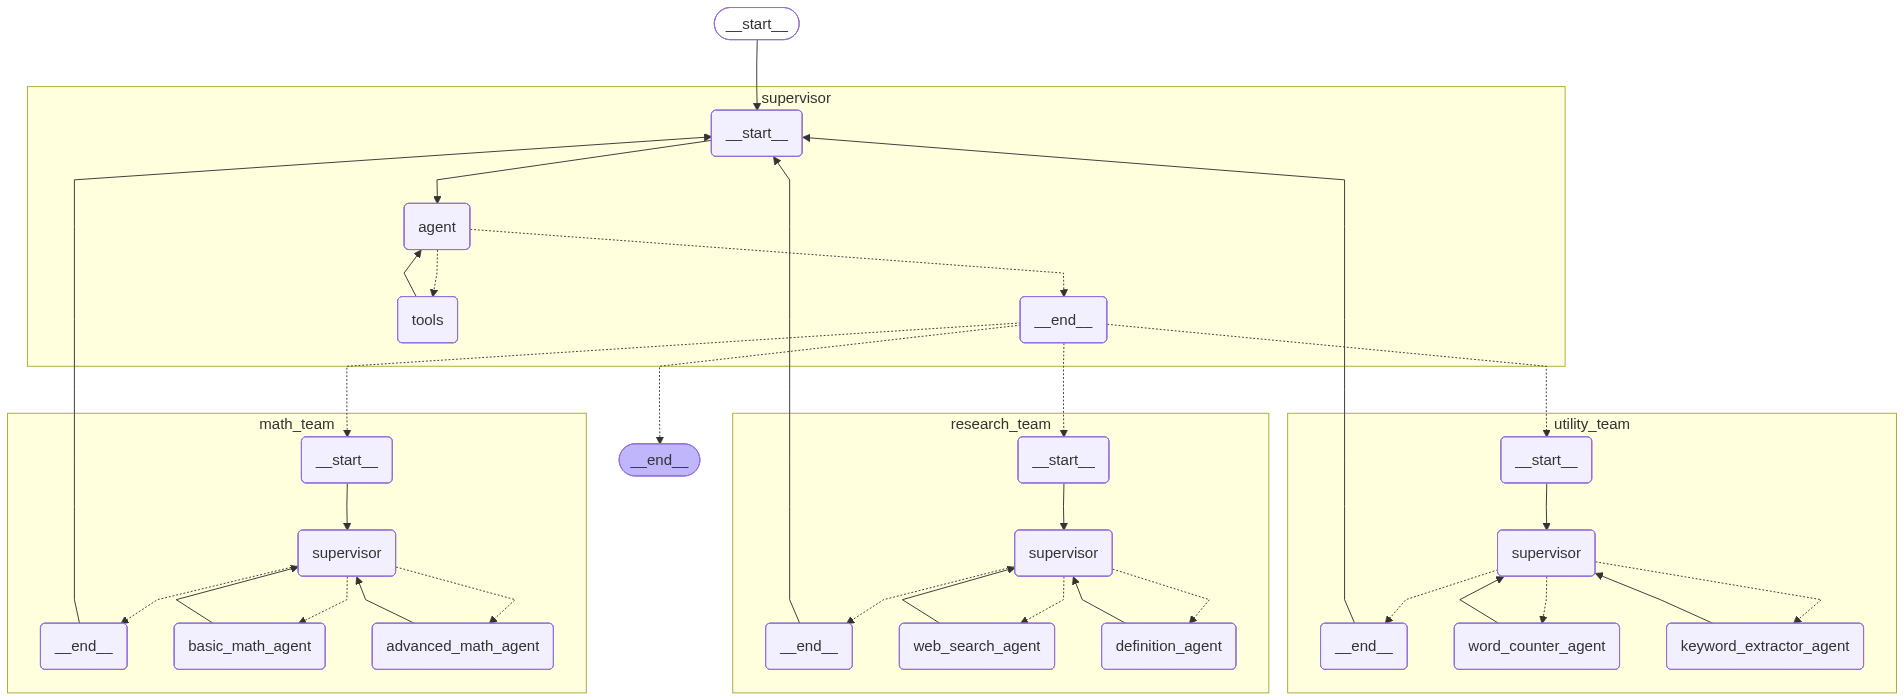

In [21]:
from IPython.display import display, Image

# xray=1 reveals the sub-supervisor nodes inside each team box
display(Image(uc4_app.get_graph(xray=1).draw_mermaid_png()))


In [22]:
# ── UC4 Example 1: Mixed query — research + math + utility in one shot ────────
uc4_result_1 = uc4_app.invoke({
    "messages": [
        {
            "role": "user",
            "content": (
                "Please do three things: "
                "1) Define the term 'neural network'. "
                "2) Calculate 2 to the power of 8. "
                "3) Count the words in this sentence: "
                "'Artificial intelligence is transforming every industry in the modern world'."
            ),
        }
    ]
})

print("=" * 70)
print("UC4 EXAMPLE 1 — Mixed: Definition + Power + Word Count")
print("=" * 70)
for msg in uc4_result_1["messages"]:
    msg.pretty_print()


UC4 EXAMPLE 1 — Mixed: Definition + Power + Word Count
================================ Human Message =================================

Please do three things: 1) Define the term 'neural network'. 2) Calculate 2 to the power of 8. 3) Count the words in this sentence: 'Artificial intelligence is transforming every industry in the modern world'.
================================== Ai Message ==================================
Name: supervisor

Here are the results of your requests:

1. **Definition of Neural Network**: A neural network (NN), also known as an artificial neural network (ANN), is a computational model inspired by the structure and functions of biological neural networks. It is used in machine learning to recognize patterns and make decisions based on input data.

2. **Calculation of 2 to the Power of 8**: The value of \(2^8\) is 256.

3. **Word Count**: The sentence "Artificial intelligence is transforming every industry in the modern world" contains 10 words.
=============

In [23]:
# ── UC4 Example 2: Pure math + keyword extraction ────────────────────────────
uc4_result_2 = uc4_app.invoke({
    "messages": [
        {
            "role": "user",
            "content": (
                "First, add 125 and 375, then multiply the result by 4. "
                "Also, extract the keywords from this text: "
                "'Deep learning models use backpropagation and gradient descent "
                "to optimise weights across multiple neural network layers'."
            ),
        }
    ]
})

print("=" * 70)
print("UC4 EXAMPLE 2 — Math Chain + Keyword Extraction")
print("=" * 70)
for msg in uc4_result_2["messages"]:
    msg.pretty_print()


UC4 EXAMPLE 2 — Math Chain + Keyword Extraction
================================ Human Message =================================

First, add 125 and 375, then multiply the result by 4. Also, extract the keywords from this text: 'Deep learning models use backpropagation and gradient descent to optimise weights across multiple neural network layers'.
================================== Ai Message ==================================
Name: supervisor

The result of adding 125 and 375 is 500, and when you multiply that by 4, you get 2000.

The extracted keywords from the text are:
- Deep learning
- models
- backpropagation
- gradient descent
- optimise
- weights
- multiple
- neural network
- layers
================================== Ai Message ==================================
Name: math_team

Transferring back to supervisor
Tool Calls:
  transfer_back_to_supervisor (c52f4923-f2ab-4e27-8495-449fac4f6c88)
 Call ID: c52f4923-f2ab-4e27-8495-449fac4f6c88
  Args:
=================================

---

## **Use Case 5: Hierarchical Insurance Claims Processing System**

### **Problem Statement**

**Title:**
Two-Level Hierarchical Supervisor Architecture for End-to-End Insurance Claims Orchestration

---

### **Problem Description**

This enterprise use case applies the **Hierarchical topology** to a realistic insurance domain workflow.
A **Root Claims Supervisor** delegates work across three specialist **Team Sub-Supervisors**, each managing a domain-specific cluster of leaf agents.

The typical enterprise question:
*"Claim CLM-5501 (auto accident, $15,000) has been submitted under policy POL-1001. Intake, assess, and resolve the claim."*

---

### **Architecture Overview**

```
                       ┌──────────────────────────────────────┐
                       │         Root Claims Supervisor       │
                       │    (End-to-End Claims Orchestrator)  │
                       └────────┬──────────────┬──────────────┘
                                │              │
          ┌─────────────────────┤              ├─────────────────────┐
          │                     │                                    │
  ┌───────▼──────────┐  ┌───────▼──────────┐  ┌────────────────────▼──────────┐
  │  Intake Team     │  │  Assessment Team  │  │  Resolution Team              │
  │  Sub-Supervisor  │  │  Sub-Supervisor   │  │  Sub-Supervisor               │
  └──┬────┬─────┬────┘  └──┬──────┬──────┬─┘  └──────┬────────┬──────────┬───┘
     │    │     │           │      │      │            │        │          │
  ┌──▼─┐  │  ┌──▼──┐      ┌─▼──┐  │   ┌──▼──┐      ┌──▼──┐   ┌▼────┐   ┌▼──────┐
  │Doc │  │  │Cov  │      │Dmg │  │   │Med  │      │Sett │   │Noti │   │Case   │
  │Cls │  │  │Val  │      │Asr │  │   │Rev  │      │Calc │   │fier │   │Closer │
  └────┘  │  └─────┘      └────┘  │   └─────┘      └─────┘   └─────┘   └───────┘
       ┌──▼──┐                  ┌──▼──┐
       │Pol  │                  │Frau │
       │Lkp  │                  │dDet │
       └─────┘                  └─────┘
```

---

### **Agent Role Descriptions**

| Level | Agent | Purpose | Tool(s) |
| ----- | ----- | ------- | ------- |
| Root | **Claims Supervisor** | Delegates to intake, assessment, resolution | None |
| L1 | **Intake Team** | Routes document & coverage tasks | Delegates |
| L1 | **Assessment Team** | Routes damage & fraud tasks | Delegates |
| L1 | **Resolution Team** | Routes settlement & closure tasks | Delegates |
| L2 | **Document Classifier** | Validates and classifies submitted documents | `classify_claim_documents()` |
| L2 | **Policy Lookup** | Retrieves policy holder details and limits | `lookup_policy()` |
| L2 | **Coverage Validator** | Confirms if damage type is covered | `validate_coverage()` |
| L2 | **Damage Assessor** | Estimates fair assessed value | `assess_damage()` |
| L2 | **Fraud Detector** | Scores claim for fraud risk | `detect_fraud_risk()` |
| L2 | **Medical Reviewer** | Validates medical claim vs standard rates | `review_medical_claim()` |
| L2 | **Settlement Calculator** | Computes net payout after deductible | `calculate_settlement()` |
| L2 | **Notifier** | Logs customer communication | `send_claim_notification()` |
| L2 | **Case Closer** | Records final resolution status | `close_claim_case()` |

---

### **Expected Output**

- **Intake**: Document completeness check, policy details, coverage confirmation
- **Assessment**: Adjusted damage value, fraud risk score, medical reasonableness
- **Resolution**: Net payout amount, customer notification, case closure record

---


In [24]:
# ── UC5 Mock Reference Data ───────────────────────────────────────────────────

POLICIES_UC5 = {
    "POL-1001": {
        "holder": "John Smith",
        "type": "comprehensive",
        "premium_annual": 1200,
        "coverage_limit": 50000,
        "deductible": 1000,
        "active": True,
        "covered_damage_types": ["accident", "theft", "natural_disaster", "medical"],
        "prior_claims_12m": 0,
    },
    "POL-2002": {
        "holder": "Sarah Lee",
        "type": "basic",
        "premium_annual": 600,
        "coverage_limit": 20000,
        "deductible": 2500,
        "active": True,
        "covered_damage_types": ["accident"],
        "prior_claims_12m": 3,
    },
    "POL-3003": {
        "holder": "Raj Patel",
        "type": "premium",
        "premium_annual": 2400,
        "coverage_limit": 100000,
        "deductible": 500,
        "active": True,
        "covered_damage_types": ["accident", "theft", "natural_disaster", "medical", "liability"],
        "prior_claims_12m": 1,
    },
}

CLAIMS_UC5 = {
    "CLM-5501": {
        "policy_id": "POL-1001",
        "damage_type": "accident",
        "reported_value": 15000.0,
        "doc_count": 5,
        "days_since_incident": 7,
        "prior_claims_36m": 1,
    },
    "CLM-5502": {
        "policy_id": "POL-2002",
        "damage_type": "medical",
        "reported_value": 28000.0,
        "doc_count": 2,
        "days_since_incident": 45,
        "prior_claims_36m": 4,
    },
    "CLM-5503": {
        "policy_id": "POL-3003",
        "damage_type": "theft",
        "reported_value": 8500.0,
        "doc_count": 4,
        "days_since_incident": 12,
        "prior_claims_36m": 2,
    },
}

MEDICAL_RATES_UC5 = {
    "mri-scan": {"standard_rate": 1200, "max_allowed": 1500, "category": "diagnostic"},
    "knee-surgery": {"standard_rate": 12000, "max_allowed": 15000, "category": "surgical"},
    "physiotherapy": {"standard_rate": 150, "max_allowed": 200, "category": "rehabilitation"},
    "emergency-room": {"standard_rate": 3500, "max_allowed": 5000, "category": "emergency"},
    "general-checkup": {"standard_rate": 200, "max_allowed": 300, "category": "preventive"},
}

DAMAGE_ADJUSTMENT_RATES = {
    "accident": 0.90,       # 10% depreciation adjustment
    "theft": 0.85,          # 15% market-value adjustment
    "natural_disaster": 0.95,
    "medical": 1.00,        # Full assessed value for medical
    "liability": 0.92,
}


In [25]:
# ── UC5 Tool Functions ────────────────────────────────────────────────────────

# --- Intake Team Tools ---

def classify_claim_documents(claim_id: str) -> str:
    """Check document completeness and classify the claim submission."""
    claim = CLAIMS_UC5.get(claim_id)
    if not claim:
        return f"[Doc Classification] ClaimID={claim_id} | ERROR: Claim not found."
    doc_count = claim["doc_count"]
    if doc_count >= 5:
        status = "COMPLETE"
        action = "Proceed to coverage validation."
    elif doc_count >= 3:
        status = "PARTIAL"
        action = "Request 1-2 additional supporting documents before assessment."
    else:
        status = "INCOMPLETE"
        action = "HOLD: Minimum 3 documents required. Notify claimant immediately."
    return (
        f"[Doc Classification] ClaimID={claim_id} | DocumentsReceived={doc_count} | "
        f"Status={status} | Action={action}"
    )


def lookup_policy(policy_id: str) -> str:
    """Retrieve policy details for the given policy ID."""
    policy = POLICIES_UC5.get(policy_id)
    if not policy:
        return f"[Policy Lookup] PolicyID={policy_id} | ERROR: Policy not found."
    active_str = "ACTIVE" if policy["active"] else "LAPSED"
    return (
        f"[Policy Lookup] PolicyID={policy_id} | Holder={policy['holder']} | "
        f"Type={policy['type']} | Status={active_str} | "
        f"CoverageLimit=${policy['coverage_limit']:,} | "
        f"Deductible=${policy['deductible']:,} | "
        f"CoveredTypes={policy['covered_damage_types']}"
    )


def validate_coverage(claim_id: str) -> str:
    """Validate whether the claim's damage type is covered under the linked policy."""
    claim = CLAIMS_UC5.get(claim_id)
    if not claim:
        return f"[Coverage Validation] ClaimID={claim_id} | ERROR: Claim not found."
    policy = POLICIES_UC5.get(claim["policy_id"])
    if not policy:
        return f"[Coverage Validation] ClaimID={claim_id} | ERROR: Policy not found."
    if not policy["active"]:
        return (
            f"[Coverage Validation] ClaimID={claim_id} | "
            f"DamageType={claim['damage_type']} | Covered=FALSE | "
            f"Reason=Policy {claim['policy_id']} is LAPSED."
        )
    covered = claim["damage_type"] in policy["covered_damage_types"]
    decision = "PROCEED to assessment." if covered else "REJECT: Damage type not covered under this policy."
    return (
        f"[Coverage Validation] ClaimID={claim_id} | "
        f"DamageType={claim['damage_type']} | PolicyType={policy['type']} | "
        f"Covered={covered} | Decision={decision}"
    )


# --- Assessment Team Tools ---

def assess_damage(claim_id: str) -> str:
    """Estimate the fair assessed value of the claim after applying adjustment rates."""
    claim = CLAIMS_UC5.get(claim_id)
    if not claim:
        return f"[Damage Assessment] ClaimID={claim_id} | ERROR: Claim not found."
    adj_rate = DAMAGE_ADJUSTMENT_RATES.get(claim["damage_type"], 0.90)
    assessed_value = round(claim["reported_value"] * adj_rate, 2)
    adjustment_pct = round((1 - adj_rate) * 100, 1)
    return (
        f"[Damage Assessment] ClaimID={claim_id} | "
        f"ReportedValue=${claim['reported_value']:,.2f} | "
        f"AdjustmentRate={adj_rate} ({adjustment_pct}% reduction) | "
        f"AssessedValue=${assessed_value:,.2f}"
    )


def detect_fraud_risk(claim_id: str) -> str:
    """Score the claim for fraud risk based on filing behaviour and history."""
    claim = CLAIMS_UC5.get(claim_id)
    if not claim:
        return f"[Fraud Detection] ClaimID={claim_id} | ERROR: Claim not found."
    score = 0
    flags = []
    if claim["prior_claims_36m"] >= 3:
        score += 35
        flags.append(f"HIGH_CLAIM_FREQUENCY(last_36m={claim['prior_claims_36m']},+35)")
    elif claim["prior_claims_36m"] >= 2:
        score += 15
        flags.append(f"ELEVATED_CLAIM_FREQUENCY(+15)")
    if claim["days_since_incident"] > 30:
        score += 20
        flags.append(f"LATE_FILING({claim['days_since_incident']}d,+20)")
    if claim["doc_count"] < 3:
        score += 25
        flags.append(f"SPARSE_DOCUMENTATION(docs={claim['doc_count']},+25)")
    policy = POLICIES_UC5.get(claim["policy_id"], {})
    if claim["reported_value"] > policy.get("coverage_limit", 99999) * 0.8:
        score += 15
        flags.append(f"HIGH_VALUE_CLAIM(+15)")
    score = min(score, 100)
    if score >= 60:
        verdict = "HIGH_FRAUD_RISK — Flag for Special Investigation Unit (SIU)."
    elif score >= 35:
        verdict = "MEDIUM_FRAUD_RISK — Assign senior adjuster for manual review."
    else:
        verdict = "LOW_FRAUD_RISK — Proceed under standard workflow."
    return (
        f"[Fraud Detection] ClaimID={claim_id} | FraudScore={score}/100 | "
        f"Flags={flags or ['NONE']} | Verdict={verdict}"
    )


def review_medical_claim(claim_id: str, procedure_code: str) -> str:
    """Validate a medical claim amount against standard procedure rates."""
    claim = CLAIMS_UC5.get(claim_id)
    if not claim:
        return f"[Medical Review] ClaimID={claim_id} | ERROR: Claim not found."
    rates = MEDICAL_RATES_UC5.get(procedure_code.lower())
    if not rates:
        return (
            f"[Medical Review] ClaimID={claim_id} | Procedure={procedure_code} | "
            f"Status=UNKNOWN_PROCEDURE — Manual review required."
        )
    claimed = claim["reported_value"]
    if claimed <= rates["max_allowed"]:
        decision = f"WITHIN LIMITS — Approve up to ${rates['max_allowed']:,}."
    else:
        decision = (
            f"EXCEEDS LIMIT — Cap reimbursement at max allowed ${rates['max_allowed']:,}. "
            f"Excess ${claimed - rates['max_allowed']:,.2f} is claimant's responsibility."
        )
    return (
        f"[Medical Review] ClaimID={claim_id} | Procedure={procedure_code} | "
        f"Category={rates['category']} | StandardRate=${rates['standard_rate']:,} | "
        f"MaxAllowed=${rates['max_allowed']:,} | ClaimedAmount=${claimed:,.2f} | "
        f"Decision={decision}"
    )


# --- Resolution Team Tools ---

def calculate_settlement(claim_id: str) -> str:
    """Compute the net settlement payout after applying the policy deductible."""
    claim = CLAIMS_UC5.get(claim_id)
    if not claim:
        return f"[Settlement] ClaimID={claim_id} | ERROR: Claim not found."
    policy = POLICIES_UC5.get(claim["policy_id"], {})
    adj_rate = DAMAGE_ADJUSTMENT_RATES.get(claim["damage_type"], 0.90)
    assessed_value = round(claim["reported_value"] * adj_rate, 2)
    deductible = policy.get("deductible", 0)
    coverage_limit = policy.get("coverage_limit", 0)
    gross_payout = max(assessed_value - deductible, 0)
    net_payout = min(gross_payout, coverage_limit)
    return (
        f"[Settlement] ClaimID={claim_id} | AssessedValue=${assessed_value:,.2f} | "
        f"Deductible=${deductible:,} | GrossPayout=${gross_payout:,.2f} | "
        f"CoverageLimit=${coverage_limit:,} | NetPayout=${net_payout:,.2f}"
    )


def send_claim_notification(claim_id: str, decision: str) -> str:
    """Log a customer-facing notification for the claim decision."""
    claim = CLAIMS_UC5.get(claim_id)
    if not claim:
        return f"[Notification] ClaimID={claim_id} | ERROR: Claim not found."
    policy = POLICIES_UC5.get(claim.get("policy_id", ""), {})
    holder = policy.get("holder", "Customer")
    return (
        f"[Notification] ClaimID={claim_id} | Recipient={holder} | "
        f"Channel=Email+SMS | Decision={decision} | "
        f"SLATarget=24h | Status=NOTIFICATION_QUEUED"
    )


def close_claim_case(claim_id: str, resolution: str) -> str:
    """Record the final resolution and close the claim case."""
    valid_resolutions = {"approved", "partially_approved", "rejected", "escalated", "siu_referred"}
    res = resolution.lower().strip()
    if res not in valid_resolutions:
        res = "escalated"
    case_ref = f"CASE-{claim_id[-4:]}"
    return (
        f"[Case Closure] ClaimID={claim_id} | CaseRef={case_ref} | "
        f"Resolution={res.upper()} | ClosedAt=NOW | "
        f"AuditTrail=RECORDED | ArchivalStatus=SCHEDULED_30D"
    )


In [26]:
from langgraph_supervisor import create_supervisor
from langgraph.prebuilt import create_react_agent

# ── Level-2: Leaf Agents ──────────────────────────────────────────────────────

doc_classifier_agent = create_react_agent(
    model=model,
    tools=[classify_claim_documents],
    name="doc_classifier_agent",
    prompt="You are a claims intake specialist. Use classify_claim_documents() to check document completeness.",
)

policy_lookup_agent = create_react_agent(
    model=model,
    tools=[lookup_policy],
    name="policy_lookup_agent",
    prompt="You are a policy records specialist. Use lookup_policy() to retrieve holder details, limits, and deductibles.",
)

coverage_validator_agent = create_react_agent(
    model=model,
    tools=[validate_coverage],
    name="coverage_validator_agent",
    prompt="You are a coverage verification specialist. Use validate_coverage() to confirm if the damage type is insured.",
)

damage_assessor_agent = create_react_agent(
    model=model,
    tools=[assess_damage],
    name="damage_assessor_agent",
    prompt="You are a property damage assessor. Use assess_damage() to compute the fair assessed value of the claim.",
)

fraud_detector_agent = create_react_agent(
    model=model,
    tools=[detect_fraud_risk],
    name="fraud_detector_agent",
    prompt="You are a fraud risk analyst. Use detect_fraud_risk() to score claims and flag suspicious patterns.",
)

medical_reviewer_agent = create_react_agent(
    model=model,
    tools=[review_medical_claim],
    name="medical_reviewer_agent",
    prompt=(
        "You are a medical claims reviewer. Use review_medical_claim() to validate "
        "claimed amounts against standard procedure rates. Use procedure codes like "
        "'mri-scan', 'knee-surgery', 'physiotherapy', 'emergency-room', 'general-checkup'."
    ),
)

settlement_calculator_agent = create_react_agent(
    model=model,
    tools=[calculate_settlement],
    name="settlement_calculator_agent",
    prompt="You are a settlement specialist. Use calculate_settlement() to compute the net payout after deductible.",
)

notifier_agent = create_react_agent(
    model=model,
    tools=[send_claim_notification],
    name="notifier_agent",
    prompt="You are a claims communication specialist. Use send_claim_notification() to log the decision notification to the customer.",
)

case_closer_agent = create_react_agent(
    model=model,
    tools=[close_claim_case],
    name="case_closer_agent",
    prompt=(
        "You are a claims case manager. Use close_claim_case() to record the final resolution. "
        "Valid resolutions: approved, partially_approved, rejected, escalated, siu_referred."
    ),
)

# ── Level-1: Team Sub-Supervisors ─────────────────────────────────────────────

intake_team_wf = create_supervisor(
    [doc_classifier_agent, policy_lookup_agent, coverage_validator_agent],
    model=model,
    prompt=(
        "You are the Intake Team leader for insurance claims. "
        "Step 1: Call doc_classifier_agent to verify document completeness. "
        "Step 2: Call policy_lookup_agent to retrieve policy details. "
        "Step 3: Call coverage_validator_agent to confirm the damage type is covered. "
        "Summarise all three results before finishing."
    ),
)
intake_team = intake_team_wf.compile()
intake_team.name = "intake_team"

assessment_team_wf = create_supervisor(
    [damage_assessor_agent, fraud_detector_agent, medical_reviewer_agent],
    model=model,
    prompt=(
        "You are the Assessment Team leader for insurance claims. "
        "Always: call damage_assessor_agent to compute assessed value. "
        "Always: call fraud_detector_agent to score the fraud risk. "
        "For medical claims: also call medical_reviewer_agent with an appropriate procedure code. "
        "Summarise all assessment results."
    ),
)
assessment_team = assessment_team_wf.compile()
assessment_team.name = "assessment_team"

resolution_team_wf = create_supervisor(
    [settlement_calculator_agent, notifier_agent, case_closer_agent],
    model=model,
    prompt=(
        "You are the Resolution Team leader for insurance claims. "
        "Step 1: Call settlement_calculator_agent to compute the final payout. "
        "Step 2: Call notifier_agent to log the notification with the decision outcome. "
        "Step 3: Call case_closer_agent to record the resolution and close the case. "
        "Provide a concise resolution summary."
    ),
)
resolution_team = resolution_team_wf.compile()
resolution_team.name = "resolution_team"

# ── Root Claims Supervisor (Level-0) ──────────────────────────────────────────

uc5_root_wf = create_supervisor(
    [intake_team, assessment_team, resolution_team],
    model=model,
    prompt=(
        "You are the Root Claims Supervisor — the top-level orchestrator for end-to-end "
        "insurance claims processing. Follow this exact sequence for every claim: "
        "1) Delegate to intake_team for document check, policy lookup, and coverage validation. "
        "2) Delegate to assessment_team for damage assessment and fraud scoring. "
        "3) Delegate to resolution_team for settlement calculation, notification, and case closure. "
        "Return a final consolidated Claims Decision Memo covering all three stages."
    ),
)

uc5_app = uc5_root_wf.compile()
print("UC5 Hierarchical Claims System compiled successfully.")
print("Nodes:", list(uc5_app.get_graph().nodes.keys()))


UC5 Hierarchical Claims System compiled successfully.
Nodes: ['__start__', 'supervisor', 'intake_team', 'assessment_team', 'resolution_team', '__end__']


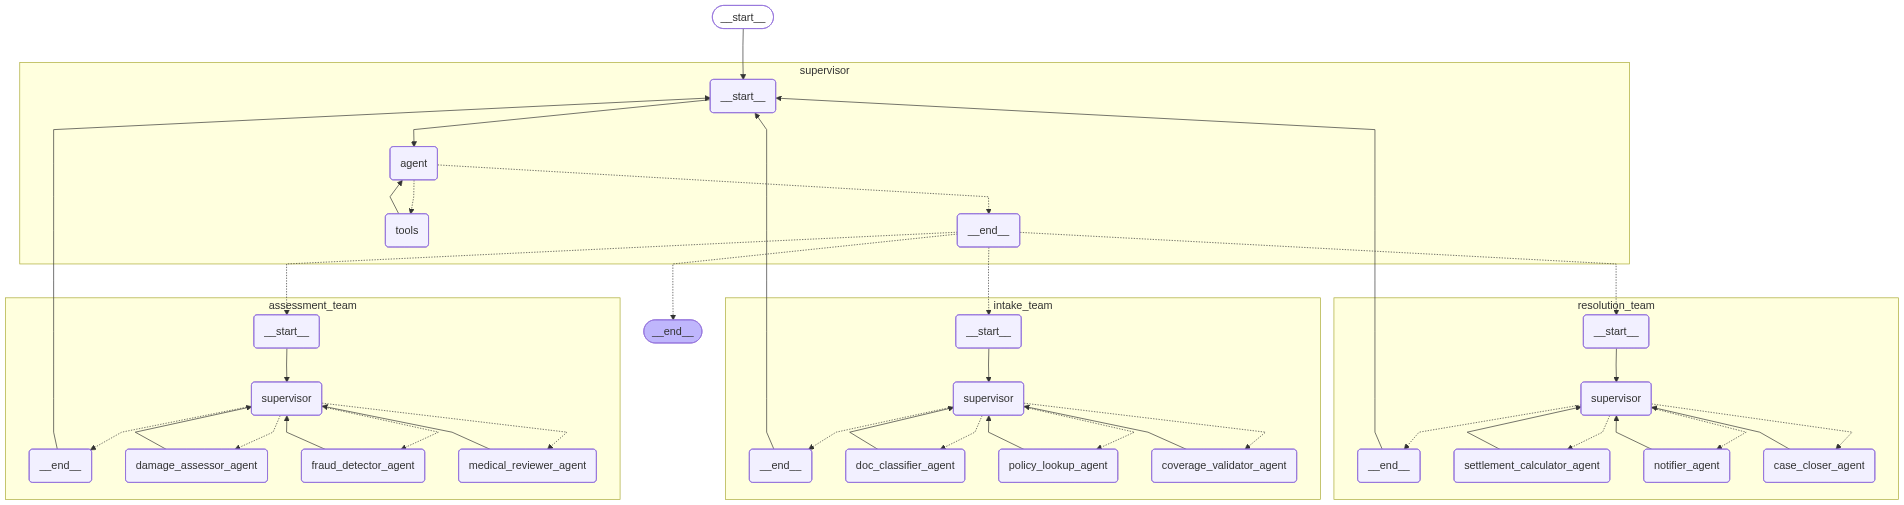

In [27]:
from IPython.display import display, Image

display(Image(uc5_app.get_graph(xray=1).draw_mermaid_png()))


In [29]:
# ── UC5 Example 1: Standard Auto Accident Claim (CLM-5501) ───────────────────
# The 3-level hierarchy (root → team → leaf agents × 9) needs more recursion steps.
uc5_result_1 = uc5_app.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": (
                    "Process insurance claim CLM-5501. "
                    "This is an auto accident claim for $15,000 filed under policy POL-1001. "
                    "Run the complete end-to-end processing: intake, assessment, and resolution."
                ),
            }
        ]
    },
    config={"recursion_limit": 150},
)

print("=" * 70)
print("UC5 EXAMPLE 1 — Auto Accident Claim CLM-5501 (POL-1001)")
print("=" * 70)
for msg in uc5_result_1["messages"]:
    msg.pretty_print()


KeyboardInterrupt: 